# Vježbe 15 — Etika, GDPR i Bias u ML modelima
**Predmet:** Rudarenje podataka — I. godina — II ciklus — Softversko inženjerstvo  
**Asistent:** ass. mr. Narcisa Hadžajlić  
**Datum:** 1.6.2026.

---

## Posljednje vježbe semestra

Prošli smo zajedno:
- MLP, CNN, Transfer Learning, LSTM, GAN tj. **kako graditi modele**
- SHAP, LIME tj. **kako modele razumjeti**

Pitanje dana: **kako modele koristiti odgovorno?**

Tehnički savršen model može nanijeti ogromnu štetu ako je nepravičan, netransparentan ili korišten bez etičkog okvira.

---

## Zašto je ovo važno za softverskog inženjera?

Vi ćete graditi sisteme koje koriste drugi ljudi. Svaki ML model koji primijeni donosi odluke koje utječu na živote:
- Sistem za odobravanje kredita odlučuje ko dobija pristup kapitalu?
- Sistem za pregled CV-ova odlučuje ko dobija poziv na intervju?
- Medicinski dijagnostički alat odlučuje ko dobija tretman?
- Sistem za procjenu recidivizma odlučuje ko ostaje u zatvoru?

**Ako model ima bias, vi ste odgovorni.** GDPR, EU AI Act i lokalni zakoni sve više to formalizuju.

### Plan:
1. Tipovi biasa - odakle dolazi nepravičnost?
2. Mjerenje biasa - fairness metrike
3. Praktični audit modela na realnom datasetu
4. Tehnike smanjenja biasa
5. GDPR u praksi - šta znači za ML inženjera
6. Završna diskusija i refleksija 

---
## 1. Tipovi biasa u ML sistemima

### 1.1 Bias u podacima

**Historical bias** — podaci reflektuju prošlu diskriminaciju. Ako su historijski žene rjeđe dobijale kredit (jer su ih banke diskriminirali), model naučen na tim podacima nastavlja tu diskriminaciju — čak i bez "spol" kolone.

**Representation bias** — određene grupe su premalo zastupljene u trening podacima. Prepoznavanje lica obučeno uglavnom na bijelim licima lošije radi za tamnopute.

**Measurement bias** — različita kvaliteta podataka za različite grupe. Ako bogati kvartovi imaju preciznije senzore kvaliteta zraka, model će davati bolje predikcije za bogate kvartove.

### 1.2 Bias u modelu

**Proxy discrimination** — model ne koristi zaštićeni atribut direktno (spol, rasa), ali koristi feature koji je visoko koreliran s njim (npr. poštanski broj ↔ etnička struktura kvarta).

**Feedback loop** — model donosi odluke → odluke mijenjaju buduće podatke → podaci pojačavaju originalni bias. Policijski model predviđa kriminal u kvartu → policija više patrolira → više uhićenja → više podataka o kriminalu u kvartu.

### 1.3 Fairness definicije — i zašto se međusobno isključuju

| Definicija | Šta znači | Problem |
|---|---|---|
| **Demographic Parity** | Ista stopa pozitivnih predikcija za sve grupe | Ignoriše stvarne razlike u distribuciji |
| **Equal Opportunity** | Isti True Positive Rate za sve grupe | Može imati različite False Positive Rate |
| **Equalized Odds** | Isti TPR i FPR za sve grupe | Matematički nemoguće uz Demographic Parity (osim trivijalni slučajevi) |
| **Individual Fairness** | Slični primjeri → slični tretman | Teško definirati "sličnost" |

> **Impossibility theorem (Chouldechova, 2017):** Nije moguće istovremeno zadovoljiti Demographic Parity, Equal Opportunity i kalibriranost — osim u trivijnim slučajevima. Morate odabrati što optimizirati.

---
## 2. Implementacija — Audit modela

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    roc_auc_score, roc_curve
)

import shap

np.random.seed(42)
print("Sve uvezeno!")

Sve uvezeno!


### 2.1 Dataset — Adult Income ("Census Income")

Klasični benchmark dataset za fairness istraživanje. Sadrži demografske podatke iz popisa SAD 1994. Target: da li osoba zarađuje >50K godišnje?

Sadrži atribute: **dob, spol, rasa, obrazovanje, zanimanje, bračni status, radno vrijeme** — idealan za demonstraciju biasa jer uključuje zaštićene atribute.

In [2]:
# Učitavanje Adult dataset
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
kolone = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'country', 'income'
]

try:
    df = pd.read_csv(url_train, names=kolone, skipinitialspace=True, na_values='?')
    print(f"Dataset učitan s UCI repozitorija: {df.shape}")
except Exception:
    print("URL nije dostupan. Generiram sintetički Adult-like dataset...")
    n = 5000
    np.random.seed(42)
    # Sintetički dataset s istom strukturom i namjerno uvedenim biasom
    df = pd.DataFrame({
        'age':            np.random.randint(18, 70, n),
        'workclass':      np.random.choice(['Private','Self-emp','Gov','Other'], n,
                                           p=[0.7,0.1,0.15,0.05]),
        'fnlwgt':         np.random.randint(50000, 500000, n),
        'education':      np.random.choice(['Bachelors','HS-grad','Masters','Doctorate','Other'], n,
                                           p=[0.3,0.35,0.15,0.05,0.15]),
        'education_num':  np.random.randint(1, 16, n),
        'marital_status': np.random.choice(['Married','Never-married','Divorced','Other'], n,
                                           p=[0.45,0.3,0.15,0.1]),
        'occupation':     np.random.choice(['Tech','Sales','Mgmt','Labor','Other'], n),
        'relationship':   np.random.choice(['Husband','Wife','Own-child','Other'], n),
        'race':           np.random.choice(['White','Black','Asian','Other'], n,
                                           p=[0.75,0.1,0.1,0.05]),
        'sex':            np.random.choice(['Male','Female'], n, p=[0.67,0.33]),
        'capital_gain':   np.where(np.random.random(n)<0.1,
                                   np.random.randint(1000,10000,n), 0),
        'capital_loss':   np.where(np.random.random(n)<0.05,
                                   np.random.randint(100,3000,n), 0),
        'hours_per_week': np.random.randint(20, 80, n),
        'country':        np.random.choice(['United-States','Other'], n, p=[0.9,0.1]),
    })
    # Target s namjernim biasom prema spolu i obrazovanju
    logit = (
        -3
        + 0.03  * df['age']
        + 0.15  * df['education_num']
        + 0.02  * df['hours_per_week']
        + 0.8   * (df['sex'] == 'Male').astype(int)       # namjerni gender bias
        + 0.4   * (df['race'] == 'White').astype(int)     # namjerni racial bias
        + 0.3   * (df['marital_status'] == 'Married').astype(int)
        + np.random.normal(0, 0.5, n)
    )
    prob = 1 / (1 + np.exp(-logit))
    df['income'] = np.where(np.random.random(n) < prob, '>50K', '<=50K')
    print(f"Sintetički dataset kreiran: {df.shape}")

# Čišćenje
df = df.dropna()
df['income'] = df['income'].str.strip().str.rstrip('.')

print(f"\nShape nakon čišćenja: {df.shape}")
print(f"Target distribucija:\n{df['income'].value_counts()}")
print(f"\nSpol distribucija:\n{df['sex'].value_counts()}")
print(f"\nRasa distribucija:\n{df['race'].value_counts()}")

Dataset učitan s UCI repozitorija: (32561, 15)

Shape nakon čišćenja: (30162, 15)
Target distribucija:
income
<=50K    22654
>50K      7508
Name: count, dtype: int64

Spol distribucija:
sex
Male      20380
Female     9782
Name: count, dtype: int64

Rasa distribucija:
race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64


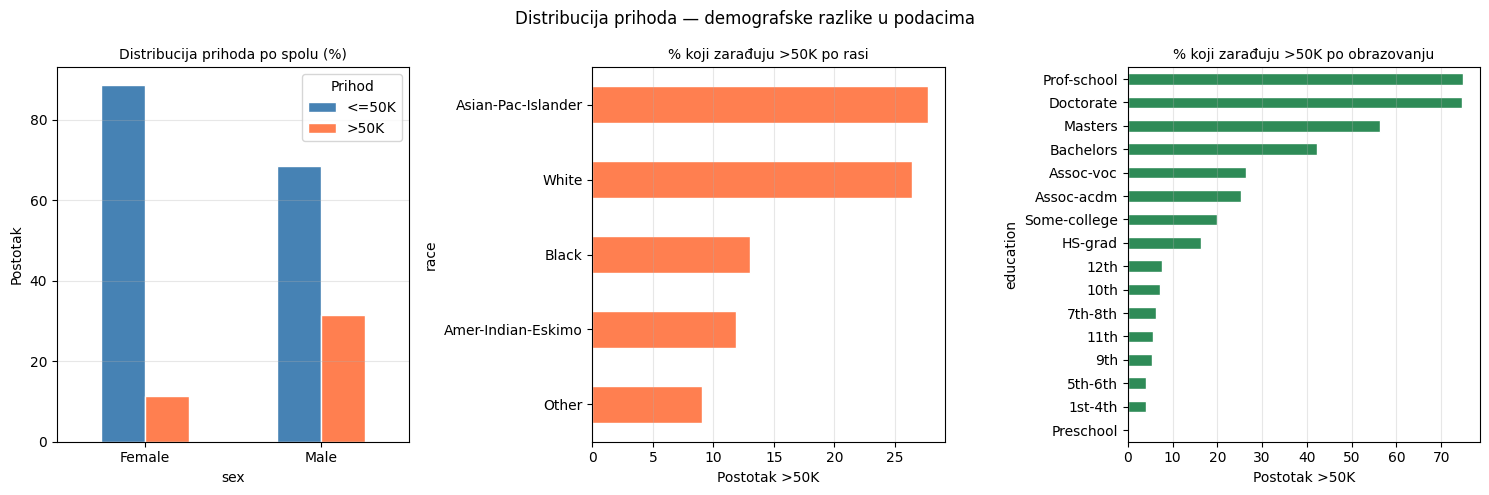

Ovo su razlike u PODACIMA — ne u modelu.
Model naučen na ovim podacima će reproducirati i možda pojačati ove razlike.


In [3]:
# Vizualizacija — distribucija prihoda po spolu i rasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Po spolu
spol_prihod = df.groupby(['sex', 'income']).size().unstack(fill_value=0)
spol_prihod_pct = spol_prihod.div(spol_prihod.sum(axis=1), axis=0) * 100
spol_prihod_pct.plot(kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('Distribucija prihoda po spolu (%)', fontsize=10)
axes[0].set_ylabel('Postotak')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Prihod')
axes[0].grid(True, alpha=0.3, axis='y')

# Po rasi
rasa_prihod = df.groupby(['race','income']).size().unstack(fill_value=0)
rasa_prihod_pct = rasa_prihod.div(rasa_prihod.sum(axis=1), axis=0) * 100
rasa_prihod_pct['>50K'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('% koji zarađuju >50K po rasi', fontsize=10)
axes[1].set_xlabel('Postotak >50K')
axes[1].grid(True, alpha=0.3, axis='x')

# Po obrazovanju
edu_prihod = df.groupby(['education','income']).size().unstack(fill_value=0)
edu_prihod_pct = edu_prihod.div(edu_prihod.sum(axis=1), axis=0) * 100
if '>50K' in edu_prihod_pct.columns:
    edu_prihod_pct['>50K'].sort_values().plot(
        kind='barh', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('% koji zarađuju >50K po obrazovanju', fontsize=10)
axes[2].set_xlabel('Postotak >50K')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Distribucija prihoda — demografske razlike u podacima',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Ovo su razlike u PODACIMA — ne u modelu.")
print("Model naučen na ovim podacima će reproducirati i možda pojačati ove razlike.")

### 2.2 Priprema podataka

In [4]:
# Enkodiranje kategoričkih varijabli
df_encoded = df.copy()

# Čuvamo originalne zaštićene atribute za fairness analizu
spol_original = df['sex'].copy()
rasa_original = df['race'].copy()

# Target enkodiranje
df_encoded['income'] = (df_encoded['income'] == '>50K').astype(int)

# Kategoričke varijable → numeričke
kat_kolone = ['workclass','education','marital_status',
              'occupation','relationship','race','sex','country']
le = LabelEncoder()
for kol in kat_kolone:
    df_encoded[kol] = le.fit_transform(df_encoded[kol].astype(str))

# Dropamo fnlwgt (statistička težina, ne prediktor)
feature_cols = [c for c in df_encoded.columns
                if c not in ['income', 'fnlwgt']]

X = df_encoded[feature_cols]
y = df_encoded['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sačuvamo indekse za fairness analizu
spol_test = spol_original.iloc[X_test.index].values
rasa_test = rasa_original.iloc[X_test.index].values

scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Features: {feature_cols}")
print(f"\nTarget: 0 = <=50K, 1 = >50K")
print(f"Balans u test skupu: {y_test.mean():.2%} zarađuje >50K")

IndexError: positional indexers are out-of-bounds

### 2.3 Trening modela

In [ ]:
# Treniramo tri modela — različite složenosti
modeli = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

rezultati = {}
for naziv, model in modeli.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    rezultati[naziv] = {
        'model':  model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1':     f1_score(y_test, y_pred, average='weighted'),
        'auc':    roc_auc_score(y_test, y_prob)
    }
    print(f"{naziv:25s}  F1: {rezultati[naziv]['f1']:.4f}  AUC: {rezultati[naziv]['auc']:.4f}")

# Koristimo RF za dalju analizu
rf        = rezultati['Random Forest']['model']
y_pred_rf = rezultati['Random Forest']['y_pred']
y_prob_rf = rezultati['Random Forest']['y_prob']

---
## 3. Fairness Audit — mjerenje biasa

In [ ]:
def fairness_metrike(y_true, y_pred, y_prob, grupa_kolona, naziv_grupe):
    """
    Izračunava fairness metrike po grupama.
    Vraća DataFrame s metrikama za svaku grupu.
    """
    grupe    = np.unique(grupa_kolona)
    metrike  = []

    for grupa in grupe:
        maska = (grupa_kolona == grupa)

        yt = y_true[maska]
        yp = y_pred[maska]
        yb = y_prob[maska]

        if len(yt) < 10:
            continue

        cm      = confusion_matrix(yt, yp, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,sum(yt))

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / Sensitivity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision
        sel = yp.mean()                                 # Selection Rate

        try:
            auc = roc_auc_score(yt, yb)
        except ValueError:
            auc = float('nan')

        metrike.append({
            naziv_grupe:       grupa,
            'N uzoraka':       int(maska.sum()),
            'Stvarno >50K (%)': f"{yt.mean()*100:.1f}%",
            'Selection Rate':  round(sel, 3),
            'TPR (Recall)':    round(tpr, 3),
            'FPR':             round(fpr, 3),
            'Precision':       round(ppv, 3),
            'AUC':             round(auc, 3),
            'F1':              round(f1_score(yt, yp, average='weighted'), 3)
        })

    return pd.DataFrame(metrike).set_index(naziv_grupe)


print("═" * 60)
print("FAIRNESS AUDIT — po spolu")
print("═" * 60)
fm_spol = fairness_metrike(
    np.array(y_test), y_pred_rf, y_prob_rf,
    spol_test, 'Spol'
)
print(fm_spol.to_string())

print("\n" + "═" * 60)
print("FAIRNESS AUDIT — po rasi")
print("═" * 60)
fm_rasa = fairness_metrike(
    np.array(y_test), y_pred_rf, y_prob_rf,
    rasa_test, 'Rasa'
)
print(fm_rasa.to_string())

In [ ]:
# Vizualizacija fairness metrika
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

metrike_za_plot = ['Selection Rate', 'TPR (Recall)', 'FPR', 'Precision', 'AUC', 'F1']
boje = plt.cm.Set2(np.linspace(0, 1, max(len(fm_spol), len(fm_rasa))))

for ax, metrika in zip(axes.flat, metrike_za_plot):
    if metrika not in fm_spol.columns:
        continue
    x      = np.arange(len(fm_spol))
    vrijednosti = fm_spol[metrika].astype(float)
    bars   = ax.bar(fm_spol.index, vrijednosti,
                    color=boje[:len(fm_spol)], edgecolor='white', width=0.5)
    ax.set_title(f'{metrika} — po spolu', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vrijednosti):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10)

plt.suptitle('Fairness metrike po spolu — nejednakost u Selection Rate,\n'
             'TPR i FPR je dokaz biasa', fontsize=11)
plt.tight_layout()
plt.show()

# Demographic Parity Difference
if 'Male' in fm_spol.index and 'Female' in fm_spol.index:
    dpd = abs(fm_spol.loc['Male','Selection Rate'] -
               fm_spol.loc['Female','Selection Rate'])
    eod = abs(fm_spol.loc['Male','TPR (Recall)'] -
               fm_spol.loc['Female','TPR (Recall)'])
    print(f"\nFairness metrike razlika (Muški vs. Ženski):")
    print(f"  Demographic Parity Difference: {dpd:.4f}")
    print(f"  (0 = savršena jednakost, >0.1 = značajan bias)")
    print(f"  Equal Opportunity Difference:  {eod:.4f}")
    print(f"  (Razlika u TPR — muški vs. ženski)")
    if dpd > 0.1:
        print(f"\n  ⚠ Demografski paritet nije zadovoljen (DPD > 0.1).")
        print(f"  Model ima statistički značajan bias po spolu.")

In [ ]:
# ROC kriva po grupama — vizualizacija razlike u performansama
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, (grupa_col, naziv, fm) in zip([ax1, ax2], [
    (spol_test, 'Spol', fm_spol),
    (rasa_test, 'Rasa', fm_rasa),
]):
    grupe = np.unique(grupa_col)
    boje  = plt.cm.tab10(np.linspace(0, 1, len(grupe)))
    for grupa, boja in zip(grupe, boje):
        maska = (grupa_col == grupa)
        yt    = np.array(y_test)[maska]
        yb    = y_prob_rf[maska]
        if len(np.unique(yt)) < 2:
            continue
        fpr_r, tpr_r, _ = roc_curve(yt, yb)
        auc_v = roc_auc_score(yt, yb)
        ax.plot(fpr_r, tpr_r, linewidth=2,
                label=f'{grupa} (AUC={auc_v:.3f})', color=boja)

    ax.plot([0,1],[0,1], 'k--', alpha=0.5, linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC kriva — po {naziv}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Razlika u AUC između grupa = nejednaka performansa modela', fontsize=11)
plt.tight_layout()
plt.show()

print("Idealna situacija: sve krive bi bile identične.")
print("Razlika u AUC znači da model manje pouzdano predviđa za neke grupe.")

---
## 4. Tehnike smanjenja biasa

In [ ]:
# ── Tehnika 1: Uklanjanje zaštićenih atributa ──────────────────────────
# Naivni pristup: ne daj modelu spol i rasu
# Problem: proxy varijable (marital_status, relationship) nose istu informaciju

zasticeni = [col for col in feature_cols
             if col in ['sex', 'race', 'relationship']]
features_bez = [c for c in feature_cols if c not in zasticeni]

X_train_bez = X_train_s[features_bez]
X_test_bez  = X_test_s[features_bez]

rf_bez = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bez.fit(X_train_bez, y_train)
y_pred_bez = rf_bez.predict(X_test_bez)
y_prob_bez = rf_bez.predict_proba(X_test_bez)[:, 1]

print("Tehnika 1: Uklanjanje zaštićenih atributa")
print(f"  Uklonjeni: {zasticeni}")
print(f"  F1 (original): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"  F1 (bez zašt.): {f1_score(y_test, y_pred_bez, average='weighted'):.4f}")

if 'Male' in spol_test and 'Female' in spol_test:
    fm_bez = fairness_metrike(np.array(y_test), y_pred_bez, y_prob_bez,
                              spol_test, 'Spol')
    if 'Male' in fm_bez.index and 'Female' in fm_bez.index:
        dpd_bez = abs(fm_bez.loc['Male','Selection Rate'] -
                      fm_bez.loc['Female','Selection Rate'])
        print(f"  DPD (original): {dpd:.4f}")
        print(f"  DPD (bez zašt.): {dpd_bez:.4f}")
        print(f"  → {'Poboljšano' if dpd_bez < dpd else 'Nije poboljšano'} — proxy varijable i dalje nose bias")

In [ ]:
# ── Tehnika 2: Threshold adjustment (post-processing) ──────────────────
# Najpraktičnija tehnika: koristite različite pragove odluke za različite grupe
# Cilj: izjednačiti Selection Rate ili TPR između grupa

def nadi_threshold(y_true, y_prob, ciljna_stopa, tolerancija=0.02):
    """Nađi threshold koji daje željenu selection rate."""
    for thresh in np.arange(0.1, 0.95, 0.01):
        sr = (y_prob >= thresh).mean()
        if abs(sr - ciljna_stopa) < tolerancija:
            return thresh
    return 0.5


y_test_arr = np.array(y_test)

# Globalna selection rate kao cilj
globalna_sr = y_pred_rf.mean()
print(f"Globalna selection rate: {globalna_sr:.3f}")

y_pred_adj = y_pred_rf.copy().astype(float)

for grupa in np.unique(spol_test):
    maska  = (spol_test == grupa)
    thresh = nadi_threshold(y_test_arr[maska],
                            y_prob_rf[maska],
                            globalna_sr)
    y_pred_adj[maska] = (y_prob_rf[maska] >= thresh).astype(float)
    sr_grupe = y_pred_adj[maska].mean()
    print(f"  {grupa}: threshold={thresh:.2f}, selection rate={sr_grupe:.3f}")

y_pred_adj = y_pred_adj.astype(int)

print(f"\nF1 (originalni threshold 0.5): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1 (prilagođeni threshold):    {f1_score(y_test, y_pred_adj, average='weighted'):.4f}")
print("\nNapomena: poboljšanje fairnessa obično dolazi uz blagi pad F1.")
print("Ovo je fundamentalni fairness-accuracy tradeoff.")

In [ ]:
# Vizualizacija fairness-accuracy tradeoffa
thresholds = np.arange(0.1, 0.9, 0.05)
f1_lista, dpd_lista = [], []

for thresh in thresholds:
    yp = (y_prob_rf >= thresh).astype(int)
    f1_lista.append(f1_score(y_test, yp, average='weighted', zero_division=0))

    sr_m = (y_prob_rf[spol_test=='Male']   >= thresh).mean() if 'Male'   in spol_test else 0
    sr_f = (y_prob_rf[spol_test=='Female'] >= thresh).mean() if 'Female' in spol_test else 0
    dpd_lista.append(abs(sr_m - sr_f))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, f1_lista,  color='steelblue', linewidth=2, label='F1 Score')
ax2.plot(thresholds, dpd_lista, color='coral',     linewidth=2,
         linestyle='--', label='Demographic Parity Diff')

ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('F1 Score', color='steelblue')
ax2.set_ylabel('Demographic Parity Difference', color='coral')
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Fairness-Accuracy Tradeoff\nPovećanje fairnessa obično smanjuje accuracy',
              fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOvo je jedan od centralnih problema etike u AI-u:")
print("Ne možemo maksimizirati i tačnost I pravičnost istovremeno.")
print("Svaki deployment zahtijeva svjesnu odluku o tom tradeoffu.")

---
## 5. SHAP za objašnjenje biasa

In [ ]:
# Koristimo SHAP da vidimo DA LI model koristi spol/rasu direktno
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_s)
shap_pos    = shap_values[1] if isinstance(shap_values, list) else shap_values

# Global SHAP importance
shap_imp = pd.Series(
    np.abs(shap_pos).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
boje_bar = ['red' if f in ['sex','race','relationship'] else 'steelblue'
            for f in shap_imp.index]
shap_imp.head(15).sort_values().plot(
    kind='barh', ax=ax,
    color=[boje_bar[list(shap_imp.index).index(f)]
           for f in shap_imp.head(15).sort_values().index]
)
ax.set_title('SHAP Feature Importance — crveno = zaštićeni atributi', fontsize=11)
ax.set_xlabel('Mean |SHAP value|')
ax.grid(True, alpha=0.3, axis='x')

crveni = mpatches.Patch(color='red',      label='Zaštićeni atribut (spol/rasa)')
plavi  = mpatches.Patch(color='steelblue',label='Ostali featuri')
ax.legend(handles=[crveni, plavi])
plt.tight_layout()
plt.show()

print("\nAko su zaštićeni atributi visoko rangirani → model ih direktno koristi.")
print("Čak i kad ih uklonimo, proxy varijable (marital_status, relationship)")
print("mogu biti korelisane sa spolom/rasom i indirektno prenositi bias.")

In [ ]:
# SHAP usporedba između grupa — da li model koristi iste feature obrasce?
if 'sex' in feature_cols:
    sex_idx = list(feature_cols).index('sex')

    mask_m = (spol_test == 'Male')
    mask_f = (spol_test == 'Female')

    shap_m = np.abs(shap_pos[mask_m]).mean(axis=0)
    shap_f = np.abs(shap_pos[mask_f]).mean(axis=0)

    top_n   = 10
    top_idx = np.argsort(shap_m + shap_f)[-top_n:]
    top_fea = [feature_cols[i] for i in top_idx]

    x = np.arange(top_n)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - 0.2, shap_m[top_idx], 0.4, label='Muški',   color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, shap_f[top_idx], 0.4, label='Ženski',  color='coral',     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(top_fea, rotation=30, ha='right')
    ax.set_title('Prosječni |SHAP| po featuri — Muški vs. Ženski\n'
                 'Razlika u visini = model ih različito tretira', fontsize=11)
    ax.set_ylabel('Mean |SHAP value|')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print("Ako model za iste featuri daje različite SHAP vrijednosti po spolu,")
    print("to je signal da model 'razmišlja' različito za muškarce i žene.")

---
## 6. GDPR u praksi — šta znači za ML inženjera

Ne studirate pravo ali svaki softverski inženjer koji radi s podacima mora razumjeti pravne okvire.

In [ ]:
# GDPR Checklist za ML sistem
checklist = {
    "Osnov za obradu (Član 6)": {
        "opis": "Svaka obrada podataka mora imati pravni osnov: pristanak, ugovor, legitimni interes...",
        "ml_implikacija": "Ne možete trenirati model na podacima bez osnova. Korišćenje osobnih podataka s interneta bez dozvole je ilegalno.",
        "pitanja": [
            "Na kom pravnom osnovu obrađujemo podatke?",
            "Je li korisnik dao eksplicitan pristanak za ML?",
        ]
    },
    "Pravo na objašnjenje (Član 22)": {
        "opis": "Lice na koje se odnosi automatizovana odluka ima pravo na smisleno objašnjenje.",
        "ml_implikacija": "Black-box modeli (duboke mreže bez XAI) mogu biti problematični za automatizovane odluke o kreditima, zapošljavanju, medicinskim dijagnozama.",
        "pitanja": [
            "Možemo li objasniti svaku odluku modela?",
            "Imamo li SHAP/LIME implementiran u produkciji?",
        ]
    },
    "Minimizacija podataka (Član 5)": {
        "opis": "Prikupljajte samo podatke koji su nužni za svrhu.",
        "ml_implikacija": "Ne koristite sve dostupne featuri samo zato što su dostupni. Feature selection nije samo pitanje performansi — i etičko je pitanje.",
        "pitanja": [
            "Koristimo li zaštićene atribute koji nisu nužni?",
            "Možemo li postići isti F1 s manje osjetljivih podataka?",
        ]
    },
    "Pravo na brisanje (Član 17)": {
        "opis": "Korisnik može zahtijevati brisanje njegovih podataka.",
        "ml_implikacija": "Ako je korisnik u trening skupu i zahtijeva brisanje — model treba biti retrainiran. Machine unlearning je aktivno istraživačko polje.",
        "pitanja": [
            "Možemo li retroaktivno ukloniti utjecaj jedne osobe iz modela?",
            "Čuvamo li trening podatke dulje nego što smijemo?",
        ]
    },
    "Procjena utjecaja (DPIA, Član 35)": {
        "opis": "Za visokorizične obrade (profiling, osjetljivi podaci) obavezna je procjena utjecaja na privatnost.",
        "ml_implikacija": "Pred deployment ML sistema koji donosi automatizovane odluke o osobama — provesti DPIA.",
        "pitanja": [
            "Je li naš model visokorizičan po GDPR definiciji?",
            "Jesmo li proveli DPIA?",
        ]
    }
}

print("GDPR CHECKLIST ZA ML SISTEME")
print("═" * 70)
for clan, info in checklist.items():
    print(f"\n▶ {clan}")
    print(f"  Opis:          {info['opis']}")
    print(f"  ML implikacija: {info['ml_implikacija']}")
    print(f"  Pitajte se:")
    for p in info['pitanja']:
        print(f"    □ {p}")

In [ ]:
# EU AI Act (2024) — novi okvir specifičan za AI sisteme
print("EU AI ACT — KLASIFIKACIJA RIZIKA")
print("═" * 70)
print("""
Unacceptable Risk (ZABRANJENO):
  ✗ Social scoring sistema od strane vlade
  ✗ Manipulativni sublimalni AI
  ✗ Real-time biometrijsko praćenje na javnim mjestima
  ✗ Prediktivno policijsko profilisanje osoba

High Risk (STROGE OBAVEZE — audit, dokumentacija, XAI):
  ⚠ Sistemi u kritičnoj infrastrukturi
  ⚠ ML za obrazovne svrhe (ocjenjivanje, primanje)
  ⚠ Sistemi zapošljavanja i upravljanja radnicima
  ⚠ Pristup osnovnim uslugama (kredit, osiguranje)
  ⚠ Sistemi kaznenog pravosuđa
  ⚠ Medicinski dijagnostički alati

Limited Risk (OBAVEZA TRANSPARENTNOSTI):
  ℹ Chatbotovi moraju biti označeni kao AI
  ℹ Deepfake sadržaj mora biti označen

Minimal Risk (slobodna upotreba):
  ✓ Spam filtri, preporučivački sistemi, igre
""")
print("Kazne za kršenje EU AI Akta: do 35 miliona EUR ili 7% globalnog prihoda.")
print("Primjenjuje se od 2026 — znači: već sada treba planirati usklađenost.")

---
## 7. Sažetak semestra — od podataka do odgovornog AI-a

In [ ]:
# Vizualizacija puta koji smo prešli
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

etape = [
    (0.5, 7.0, "Vj. 1–7\n(Faris)",
     "Preprocessing\nKlasifikacija\nKlasterovanje", '#AED6F1'),
    (2.5, 7.0, "Vj. 8\nMLP",
     "Forward pass\nBackprop\nLoss kriva", '#A9DFBF'),
    (4.3, 7.0, "Vj. 9\nRegularizacija",
     "Dropout\nBatch Norm\nOverfitting", '#A9DFBF'),
    (6.1, 7.0, "Vj. 10\nCNN",
     "Konvolucija\nFeature maps\nPooling", '#A9DFBF'),
    (7.9, 7.0, "Vj. 11\nTransfer",
     "VGG16\nFine-tuning\nMali dataset", '#A9DFBF'),

    (1.5, 4.2, "Vj. 12\nLSTM",
     "Trend\nSezonalnost\nVremenske serije", '#F9E79F'),
    (3.8, 4.2, "Vj. 13\nGAN/cGAN",
     "Generator\nDiscriminator\nGenerativni AI", '#F9E79F'),
    (6.1, 4.2, "Vj. 14\nXAI",
     "SHAP\nLIME\nObjašnjivost", '#F9E79F'),
    (8.4, 4.2, "Vj. 15\nEtika",
     "Bias\nGDPR\nOdgovornost", '#F1948A'),
]

for x, y, naziv, opis, boja in etape:
    rect = mpatches.FancyBboxPatch(
        (x - 0.85, y - 0.9), 1.7, 1.7,
        boxstyle="round,pad=0.1",
        facecolor=boja, edgecolor='gray', linewidth=1
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.45, naziv, ha='center', va='center',
            fontsize=8.5, fontweight='bold')
    ax.text(x, y - 0.3, opis, ha='center', va='center',
            fontsize=7, color='#333333')

# Legenda faza
for boja_l, tekst_l, xp, yp in [
    ('#AED6F1', 'Faza 1 (Faris) — Osnove ML',         1.5, 1.5),
    ('#A9DFBF', 'Faza 2 — Duboke mreže',              4.0, 1.5),
    ('#F9E79F', 'Faza 3 — Specijalizacija',           6.5, 1.5),
    ('#F1948A', 'Faza 4 — Etika i odgovornost',       8.8, 1.5),
]:
    rect = mpatches.FancyBboxPatch(
        (xp - 1.2, yp - 0.3), 2.4, 0.6,
        boxstyle="round,pad=0.05",
        facecolor=boja_l, edgecolor='gray', linewidth=0.8
    )
    ax.add_patch(rect)
    ax.text(xp, yp, tekst_l, ha='center', va='center', fontsize=7)

ax.set_title('Rudarenje podataka 2025/26 — Put koji smo prešli',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 8. Šta smo naučili danas

| Koncept | Šta znači |
|---|---|
| **Historical bias** | Podaci reflektuju prošlu diskriminaciju |
| **Proxy discrimination** | Indirektan bias kroz korelisane varijable |
| **Demographic Parity** | Ista stopa pozitivnih predikcija za sve grupe |
| **Equal Opportunity** | Isti TPR za sve grupe |
| **DPD** | Demographic Parity Difference — mjera biasa (0=savršeno) |
| **Feedback loop** | Model pojačava vlastiti bias kroz nove podatke |
| **Threshold adjustment** | Post-processing tehnika za smanjenje biasa |
| **Fairness-accuracy tradeoff** | Veća pravičnost obično znači nižu accuracy |
| **GDPR Član 22** | Pravo na objašnjenje automatizovane odluke |
| **EU AI Act** | Klasifikacija AI rizika — High Risk zahtijeva audit |
| **DPIA** | Data Protection Impact Assessment — obavezno za High Risk AI |

---
## Hvala!

Prošli smo od osnova ML-a do generativnih modela, od crnih kutija do objašnjivih sistema, i završili s pitanjima koja su zapravo najvažnija: **Kome naš model služi? Kome može naškoditi? Kako to znamo?**

